In [63]:
import json
import numpy as np
import seaborn as sns
import pandas as pd
import mne
from mne.io import read_raw_eeglab
from mne.viz import plot_sensors
from mne.preprocessing import ICA

In [77]:
file = open('/Users/Ethan/Desktop/Machine learning downloads/ds003774/sub-001/ses-01/eeg/sub-001_ses-01_task-MusicListening_run-1_eeg.json','r')
egg_metadata= json.load(file)
egg_metadata

{'PowerLineFrequency': 50,
 'SoftwareFilters': {'FilterDescription': {'Description': 'None'}},
 'HardwareFilters': {'FilterDescription': {'Description': 'None'}},
 'SoftwareVersions': 'Netstation 5.4',
 'ManufacturersModelName': 'NetAmps 400',
 'Manufacturer': 'MagstimEG',
 'EEGPlacementScheme': 'EGI',
 'EEGGround': 'None',
 'EEGReference': 'Cz',
 'CapManufacturersModelName': '128 channel HCGSN (Hydrocel Geodesic Sensor Net)',
 'CapManufacturer': 'Magstim EGI',
 'InstitutionAddress': 'India',
 'InstitutionName': 'Indian Institute of Technology Gandhinanagar',
 'Instructions': 'The first question asked them to rate their familiarity with the song on a scale of 1 to 5, where 1 indicated extreme familiarity and 5 indicated extreme unfamiliarity to the song. The second question asked them to rate their enjoyment of the song on a scale of 1 to 5, where 1 indicated extremely enjoyable and 5 indicated extremely unenjoyable song.',
 'TaskDescription': 'The participants sat comfortably in a dar

In [10]:
channels_df = pd.read_csv('/Users/Ethan/Desktop/Machine learning downloads/ds003774/sub-001/ses-01/eeg/sub-001_ses-01_task-MusicListening_run-1_channels.tsv', sep='\t')
print(channels_df.head)

<bound method NDFrame.head of      name type   units
0      E1  EEG  microV
1      E2  EEG  microV
2      E3  EEG  microV
3      E4  EEG  microV
4      E5  EEG  microV
..    ...  ...     ...
124  E125  EEG  microV
125  E126  EEG  microV
126  E127  EEG  microV
127  E128  EEG  microV
128  E129  EEG  microV

[129 rows x 3 columns]>


In [19]:
raw = read_raw_eeglab('/Users/Ethan/Desktop/Machine learning downloads/ds003774/sub-001/ses-01/eeg/sub-001_ses-01_task-MusicListening_run-1_eeg.set', preload = True)
print(raw.info)

<Info | 8 non-empty values
 bads: []
 ch_names: E1, E2, E3, E4, E5, E6, E7, E8, E9, E10, E11, E12, E13, E14, ...
 chs: 129 EEG
 custom_ref_applied: False
 dig: 132 items (3 Cardinal, 129 EEG)
 highpass: 0.0 Hz
 lowpass: 125.0 Hz
 meas_date: unspecified
 nchan: 129
 projs: []
 sfreq: 250.0 Hz
>


/var/folders/2_/xrftwqdx3xq0bmmzkn0x7jbc0000gp/T/ipykernel_3495/1406886911.py:1: RuntimeWarning: Omitted 106 annotation(s) that were outside data range.
  raw = read_raw_eeglab('/Users/Ethan/Desktop/Machine learning downloads/ds003774/sub-001/ses-01/eeg/sub-001_ses-01_task-MusicListening_run-1_eeg.set', preload = True)
/var/folders/2_/xrftwqdx3xq0bmmzkn0x7jbc0000gp/T/ipykernel_3495/1406886911.py:1: RuntimeWarning: Limited 2 annotation(s) that were expanding outside the data range.
  raw = read_raw_eeglab('/Users/Ethan/Desktop/Machine learning downloads/ds003774/sub-001/ses-01/eeg/sub-001_ses-01_task-MusicListening_run-1_eeg.set', preload = True)
/var/folders/2_/xrftwqdx3xq0bmmzkn0x7jbc0000gp/T/ipykernel_3495/1406886911.py:1: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = read_raw_eeglab('/Users/Ethan/Desktop/Machine learning downloads/ds003774/sub-001/ses-01/eeg/sub-001_ses-01_task

Using matplotlib as 2D backend.


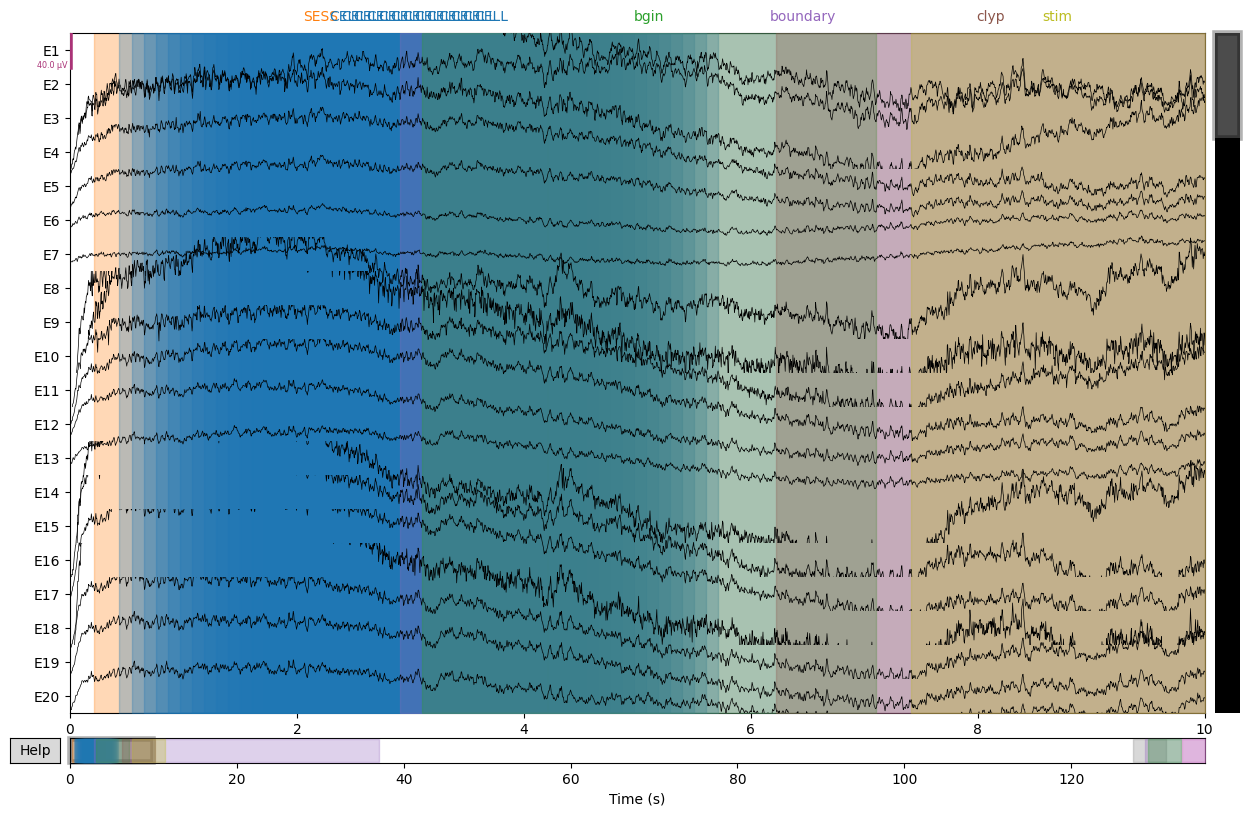

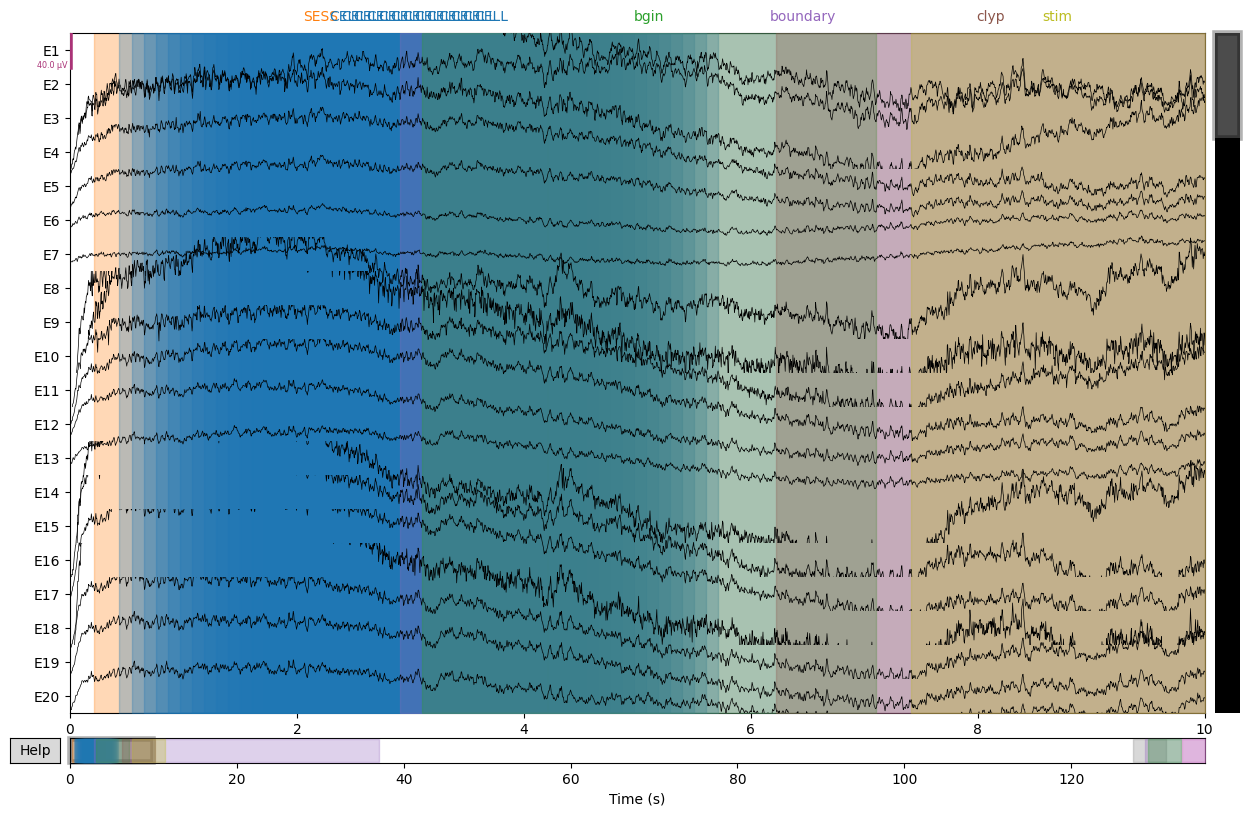

In [20]:
raw.plot()

In [26]:
raw.filter(0.5,40)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1651 samples (6.604 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    1.5s


<RawEEGLAB | sub-001_ses-01_task-MusicListening_run-1_eeg.set, 129 x 34009 (136.0 s), ~33.6 MiB, data loaded>

Fitting ICA to data using 129 channels (please be patient, this may take a while)
Selecting by number: 15 components
Fitting ICA took 2.0s.


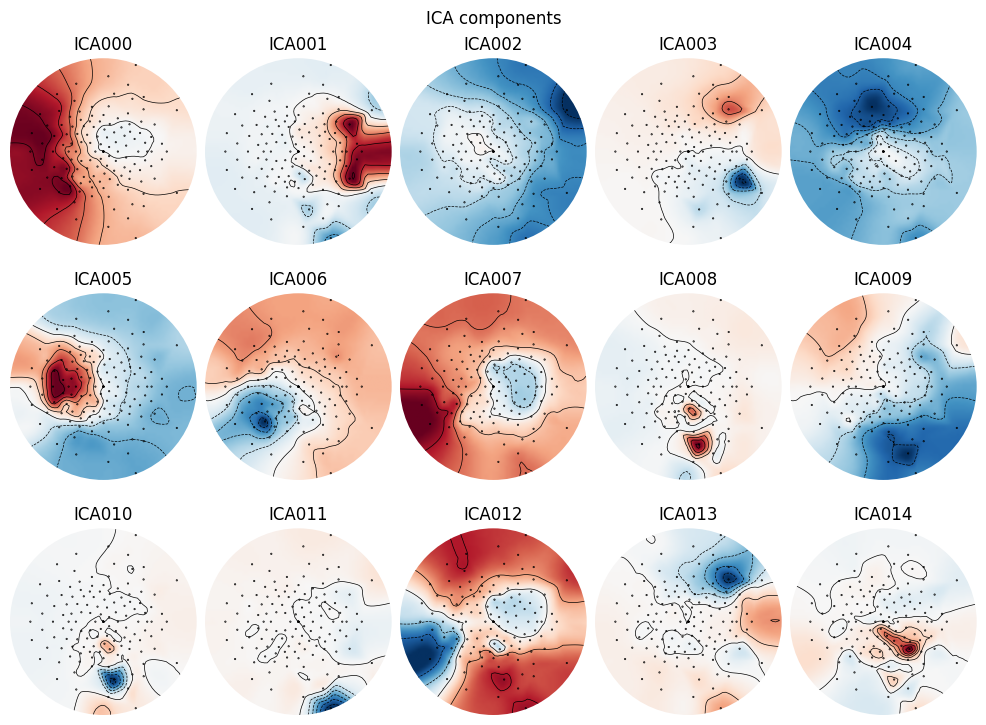

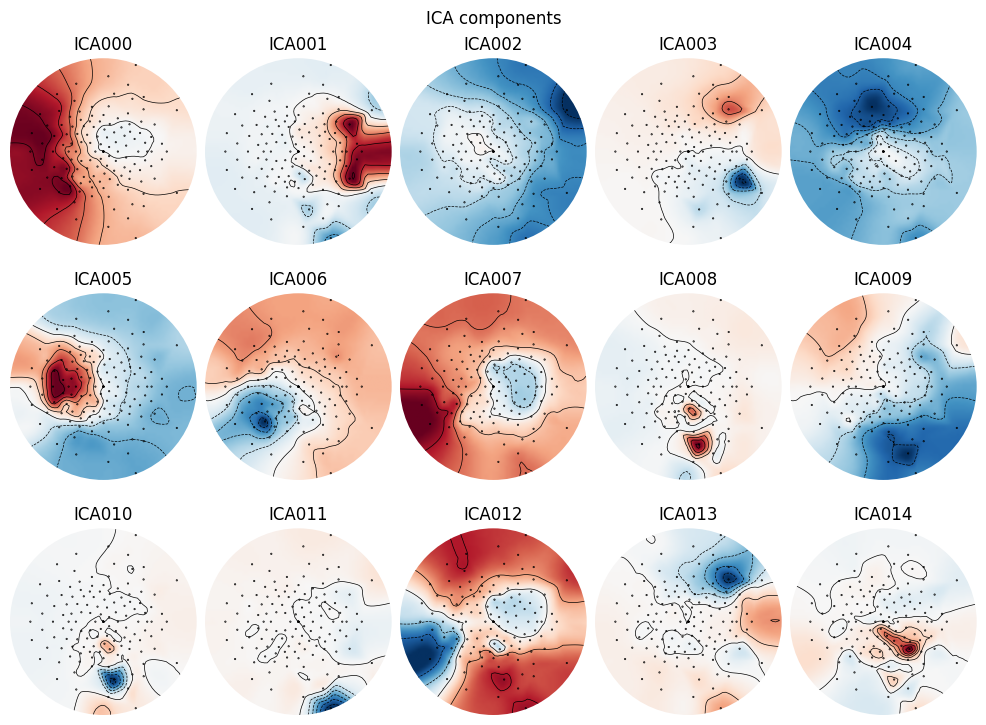

In [70]:
ind_com_analysis = ICA(n_components=15, random_state=97)
ind_com_analysis.fit(raw)
ind_com_analysis.plot_components()

In [72]:
print(raw.annotations)
events, event_dict = mne.events_from_annotations(raw)
print('Events array:\n', events)
print('Events dictionary:\n', event_dict)

<Annotations | 22 segments: CELL (13), SESS (1), bgin (2), boundary (2), ...>
Used Annotations descriptions: [np.str_('CELL'), np.str_('SESS'), np.str_('bgin'), np.str_('boundary'), np.str_('clyp'), np.str_('fxcl'), np.str_('opyp'), np.str_('stim')]
Events array:
 [[   53     0     2]
 [  109     0     1]
 [  136     0     1]
 [  162     0     1]
 [  189     0     1]
 [  216     0     1]
 [  242     0     1]
 [  269     0     1]
 [  295     0     1]
 [  322     0     1]
 [  348     0     1]
 [  375     0     1]
 [  401     0     1]
 [  428     0     1]
 [  727     0     4]
 [  777     0     3]
 [ 1556     0     5]
 [ 1852     0     8]
 [31852     0     7]
 [32225     0     4]
 [32287     0     3]
 [33321     0     6]]
Events dictionary:
 {np.str_('CELL'): 1, np.str_('SESS'): 2, np.str_('bgin'): 3, np.str_('boundary'): 4, np.str_('clyp'): 5, np.str_('fxcl'): 6, np.str_('opyp'): 7, np.str_('stim'): 8}


In [78]:
epochs = mne.Epochs(raw, events, tmin=-0.2, tmax=0.8, baseline=(None, 0))
epochs

Not setting metadata
22 matching events found
Setting baseline interval to [-0.2, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated


<Epochs | 22 events (good & bad), -0.2 – 0.8 s (baseline -0.2 – 0 s), ~146 KiB, data not loaded,
 '1': 13
 '2': 1
 '3': 2
 '4': 2
 '5': 1
 '6': 1
 '7': 1
 '8': 1>

Using data from preloaded Raw for 22 events and 251 original time points ...
0 bad epochs dropped
Using data from preloaded Raw for 20 events and 251 original time points ...


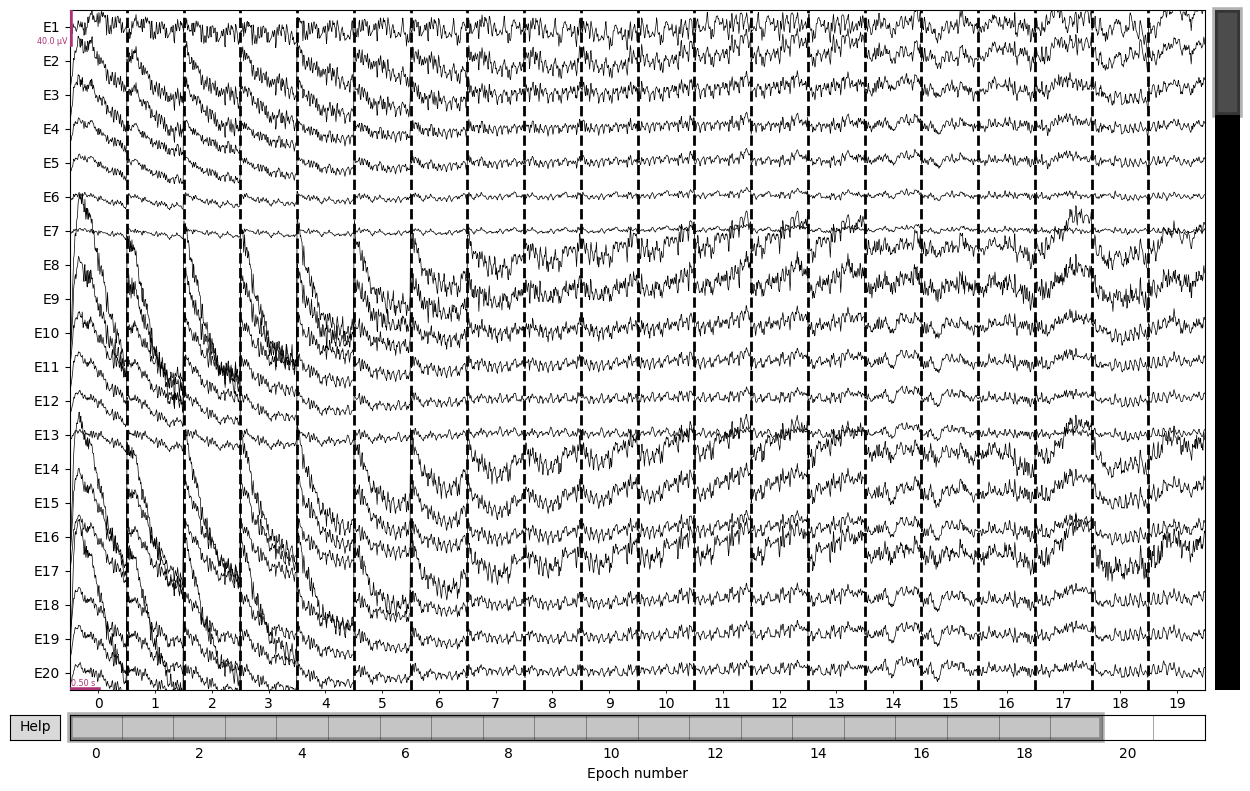

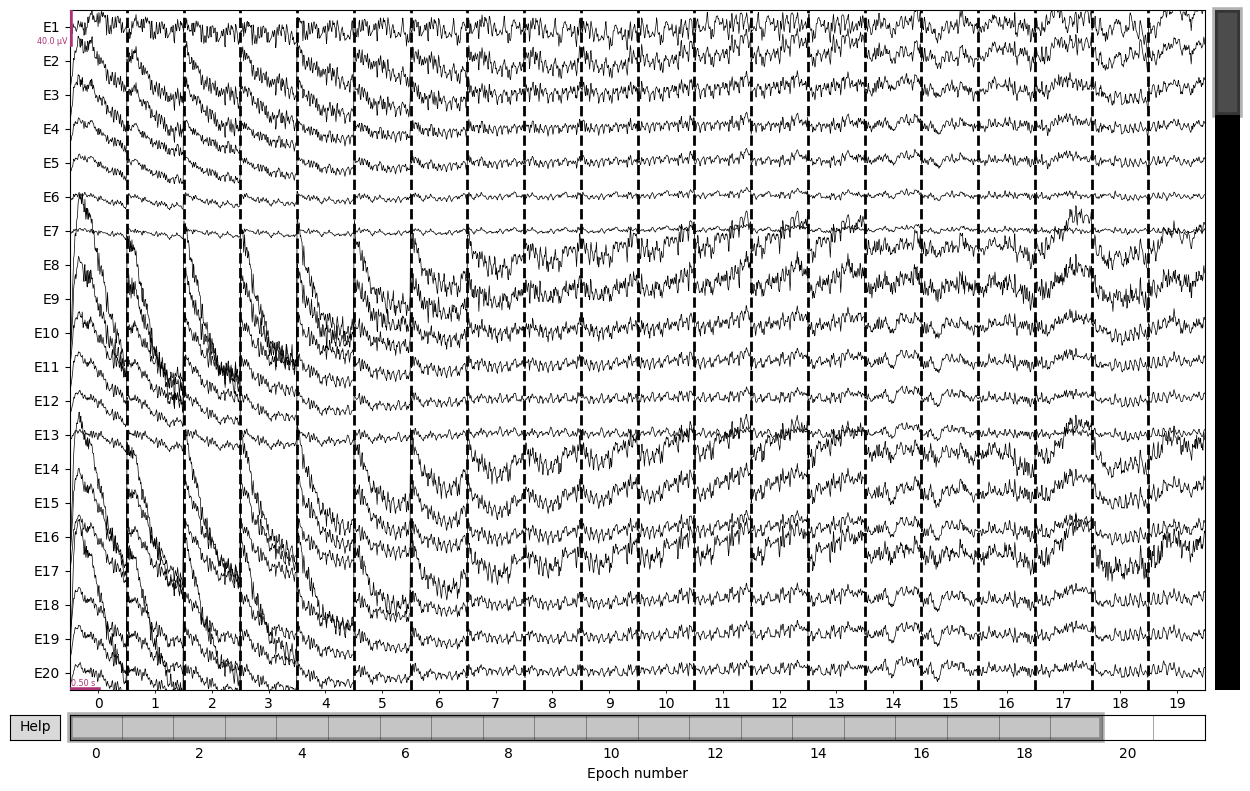

In [76]:
epochs.plot()

In [52]:
events_df = pd.read_csv('/Users/Ethan/Desktop/Machine learning downloads/ds003774/sub-001/ses-01/eeg/sub-001_ses-01_task-MusicListening_run-1_events.tsv',sep='\t')
print(events_df.head)

<bound method NDFrame.head of            onset  duration       sample  trial_type  response_time  stim_file  \
0       0.212676    1000.0      53.1689         NaN            NaN        NaN   
1       0.434672    1000.0     108.6680         NaN            NaN        NaN   
2       0.543674    1000.0     135.9184         NaN            NaN        NaN   
3       0.649678    1000.0     162.4195         NaN            NaN        NaN   
4       0.756678    1000.0     189.1695         NaN            NaN        NaN   
..           ...       ...          ...         ...            ...        ...   
123  1999.875681    1000.0  499968.9203         NaN            NaN        NaN   
124  2003.027676    1000.0  500756.9189         NaN            NaN        NaN   
125  2003.036678    1000.0  500759.1694         NaN            NaN        NaN   
126  2003.045680    1000.0  500761.4200         NaN            NaN        NaN   
127  2003.048677    1000.0  500762.1693         NaN            NaN        NaN  

In [57]:
sns.countplot(x='trial_type',data= events_df)

<Axes: xlabel='trial_type', ylabel='count'>

In [85]:
electrodes_df = pd.read_csv('/Users/Ethan/Desktop/Machine learning downloads/ds003774/sub-001/ses-01/eeg/sub-001_ses-01_task-MusicListening_run-1_electrodes.tsv', sep='\t')
print(electrodes_df.head())
#montage = mne.channels.read_custom_montage('/Users/Ethan/Desktop/Machine learning downloads/ds003774/sub-001/ses-01/eeg/sub-001_ses-01_task-MusicListening_run-1_electrodes.tsv')
#raw.set_montage(montage)
#raw.plot_sensors()

  name     x     y     z
0   E1  6.30 -6.61 -2.94
1   E2  7.66 -6.04  0.35
2   E3  8.72 -4.41  3.50
3   E4  8.16 -3.28  5.70
4   E5  6.49 -1.69  7.78


In [84]:
#cordinate_file = open('/Users/Ethan/Desktop/Machine learning downloads/ds003774/sub-001/ses-01/eeg/sub-001_ses-01_task-MusicListening_run-1_coordsystem.json','r')
#cordinate_system = json.load(cordinate_file)
#cordinate_system

{'EEGCoordinateUnits': 'mm',
 'EEGCoordinateSystem': 'Other',
 'EEGCoordinateSystemDescription': 'EEGLAB'}

[<DigPoint |        LPA : (-500.0, 0.0, 0.0) mm     : head frame>, <DigPoint |     Nasion : (0.0, 500.0, 0.0) mm      : head frame>, <DigPoint |        RPA : (500.0, 0.0, 0.0) mm      : head frame>, <DigPoint |     EEG #1 : (6300.0, -6610.0, -2940.0) mm : head frame>, <DigPoint |     EEG #2 : (7660.0, -6040.0, 350.0) mm : head frame>, <DigPoint |     EEG #3 : (8720.0, -4410.0, 3500.0) mm : head frame>, <DigPoint |     EEG #4 : (8160.0, -3280.0, 5700.0) mm : head frame>, <DigPoint |     EEG #5 : (6490.0, -1690.0, 7780.0) mm : head frame>, <DigPoint |     EEG #6 : (4350.0, 0.0, 9010.0) mm  : head frame>, <DigPoint |     EEG #7 : (1780.0, 1400.0, 9640.0) mm : head frame>, <DigPoint |     EEG #8 : (9130.0, -4820.0, -1550.0) mm : head frame>, <DigPoint |     EEG #9 : (10140.0, -3080.0, 1240.0) mm : head frame>, <DigPoint |    EEG #10 : (9940.0, -2090.0, 3640.0) mm : head frame>, <DigPoint |    EEG #11 : (9090.0, 0.0, 5760.0) mm  : head frame>, <DigPoint |    EEG #12 : (6490.0, 1690.0, 7780.

/var/folders/2_/xrftwqdx3xq0bmmzkn0x7jbc0000gp/T/ipykernel_3495/593022920.py:7: RuntimeWarning: Omitted 106 annotation(s) that were outside data range.
  raw = mne.io.read_raw_eeglab('/Users/Ethan/Desktop/Machine learning downloads/ds003774/sub-001/ses-01/eeg/sub-001_ses-01_task-MusicListening_run-1_eeg.set', preload = True)
/var/folders/2_/xrftwqdx3xq0bmmzkn0x7jbc0000gp/T/ipykernel_3495/593022920.py:7: RuntimeWarning: Limited 2 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab('/Users/Ethan/Desktop/Machine learning downloads/ds003774/sub-001/ses-01/eeg/sub-001_ses-01_task-MusicListening_run-1_eeg.set', preload = True)
/var/folders/2_/xrftwqdx3xq0bmmzkn0x7jbc0000gp/T/ipykernel_3495/593022920.py:7: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab('/Users/Ethan/Desktop/Machine learning downloads/ds003774/sub-001/ses-01/eeg/s

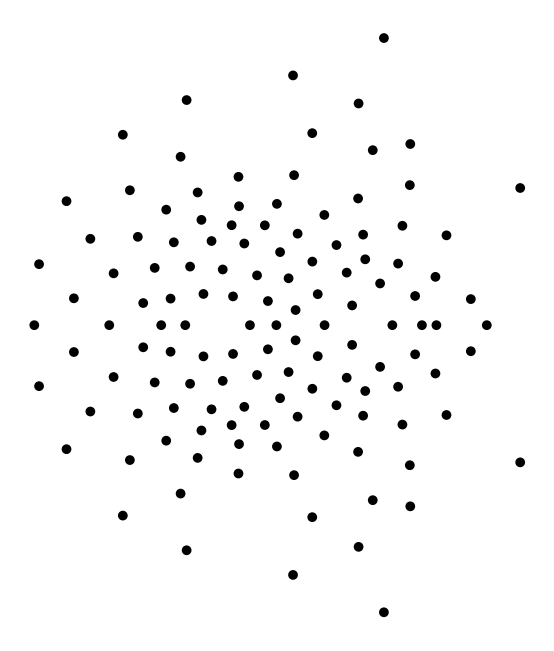

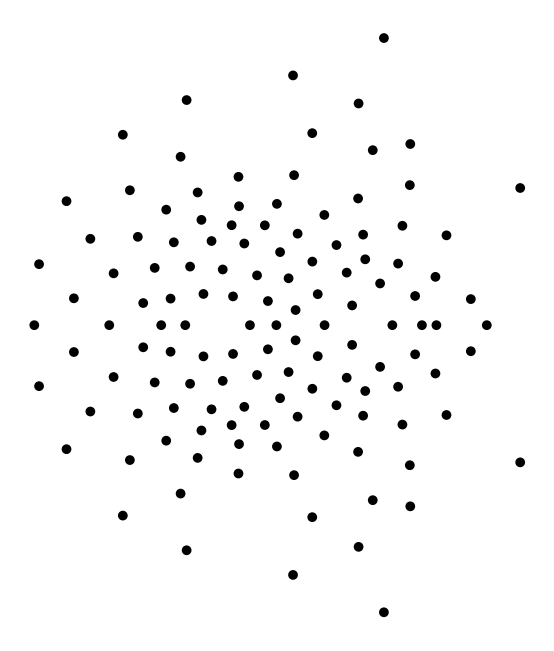

In [90]:
import mne
import pandas as pd
import json
from mne.channels import make_dig_montage

# Load EEG data
raw = mne.io.read_raw_eeglab('/Users/Ethan/Desktop/Machine learning downloads/ds003774/sub-001/ses-01/eeg/sub-001_ses-01_task-MusicListening_run-1_eeg.set', preload = True)

# Load the electrodes.tsv file
electrodes_df = pd.read_csv('/Users/Ethan/Desktop/Machine learning downloads/ds003774/sub-001/ses-01/eeg/sub-001_ses-01_task-MusicListening_run-1_electrodes.tsv', sep='\t')

# Load the coordsystem.json file
with open('/Users/Ethan/Desktop/Machine learning downloads/ds003774/sub-001/ses-01/eeg/sub-001_ses-01_task-MusicListening_run-1_coordsystem.json','r') as f:
    coordsystem = json.load(f)

# Create a montage from the electrodes DataFrame
montage = make_dig_montage(
    ch_pos=dict(zip(electrodes_df['name'], electrodes_df[['x', 'y', 'z']].values)),
    nasion=[0, 0.5, 0],  # Update based on coordsystem.json
    lpa=[-0.5, 0, 0],    # Update based on coordsystem.json
    rpa=[0.5, 0, 0]      # Update based on coordsystem.json
)

# Set the montage for the raw object
raw.set_montage(montage)

# Verify the montage
print(raw.info['dig'])
raw.plot_sensors()